In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

import re
import os
import sys

sys.path.append(os.path.abspath('../'))

In [27]:
file_path = '../data/processed/X_train_scaled.csv'
X_train_scaled = pd.read_csv(file_path)

file_path1 = '../data/processed/X_test_scaled.csv'
X_test_scaled = pd.read_csv(file_path1)

file_path2 = '../data/processed/y_train.csv'
y_train = pd.read_csv(file_path2)

file_path3 = '../data/processed/y_test.csv'
y_test = pd.read_csv(file_path3)

In [28]:
# Khởi tạo mô hình và học
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# thử trên tập test
lr_preds = lr_model.predict(X_test_scaled)
r2_lr = r2_score(y_test, lr_preds)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_preds))
mae_lr = mean_absolute_error(y_test, lr_preds)

print(f"R^2: {r2_lr:.4f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")

R^2: 0.4392
RMSE: 115.81
MAE: 79.09


In [29]:
import joblib
joblib.dump(lr_model, '../models/linear_regression_model.pkl')

['../models/linear_regression_model.pkl']

In [30]:
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Mức độ tác động giá': lr_model.coef_.flatten()
}).sort_values(by='Mức độ tác động giá', ascending=False)

display(coefficients.head(5))

display(coefficients.tail(5))

,Feature,Mức độ tác động giá
1,accommodates,76.696836
22,amenities_count,28.780158
23,property_type_Hotel_B_and_B,26.308372
7,calculated_host_listings_count,25.198880
32,neighbourhood_cleansed_East Cambridge,21.549213


,Feature,Mức độ tác động giá
35,neighbourhood_cleansed_North Cambridge,-15.103184
13,has_carbon_monoxide_alarm,-17.876318
27,has_review,-26.604501
11,room_type_Private room,-26.865172
16,has_hangers,-28.475357


In [31]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

#train
rf_model.fit(X_train_scaled, y_train)

#test
rf_preds = rf_model.predict(X_test_scaled)

r2_rf = r2_score(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))
mae_rf = mean_absolute_error(y_test, rf_preds)

print(f"R^2: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")

d:\Python\python_evn\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R^2: 0.6774
RMSE: 87.84
MAE: 52.33


In [32]:
import joblib
joblib.dump(rf_model, '../models/random_forest_model.pkl')

['../models/random_forest_model.pkl']

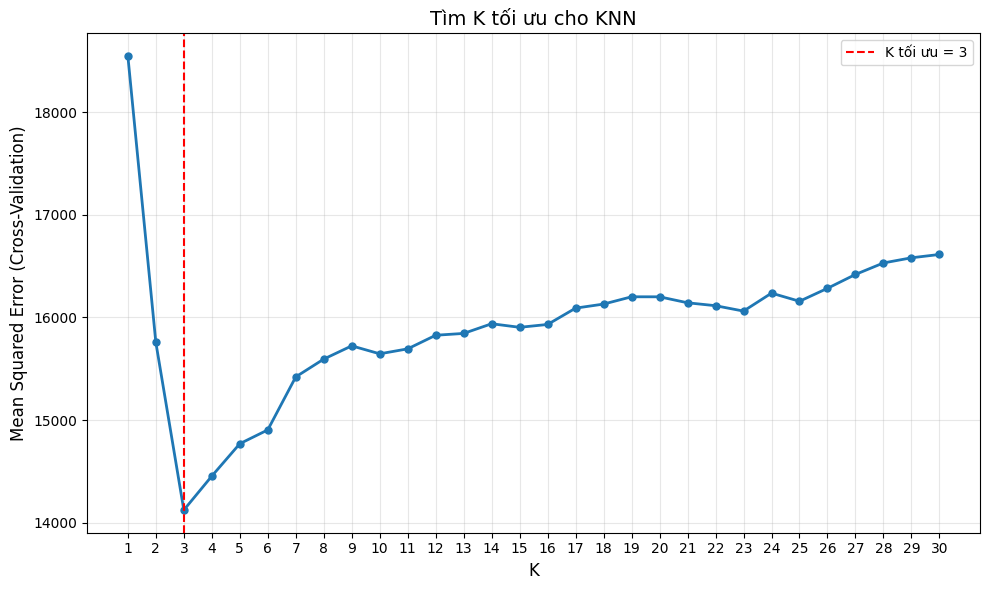

K tối ưu: 3
MSE tại K=3: 14122.3349


In [33]:
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    # Cross-validation 5-fold, dùng negative MSE (sklearn convention)
    scores = cross_val_score(knn, X_train_scaled, y_train.values.ravel(), 
                            cv=5, scoring='neg_mean_squared_error')
    k_scores.append(-scores.mean())  # Chuyển về MSE dương
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o', linewidth=2, markersize=5)
plt.xlabel('K', fontsize=12)
plt.ylabel('Mean Squared Error (Cross-Validation)', fontsize=12)
plt.title('Tìm K tối ưu cho KNN', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Đánh dấu k tối ưu
optimal_k = k_range[np.argmin(k_scores)]
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'K tối ưu = {optimal_k}')
plt.legend()
plt.tight_layout()

plt.savefig('../reports/figures/k_toi_uu.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"K tối ưu: {optimal_k}")
print(f"MSE tại K={optimal_k}: {min(k_scores):.4f}")

In [34]:
knn_model = KNeighborsRegressor(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train.values.ravel())
knn_preds = knn_model.predict(X_test_scaled)
# Đánh giá model
r2_knn = r2_score(y_test, knn_preds)
rmse_knn = np.sqrt(mean_squared_error(y_test, knn_preds))
mae_knn = mean_absolute_error(y_test, knn_preds)

print(f"Kết quả KNN (K = {optimal_k})")
print(f"R²:  {r2_knn:.4f}")
print(f"RMSE: {rmse_knn:.2f}")
print(f"MAE: {mae_knn:.2f}")

Kết quả KNN (K = 3)
R²:  0.6351
RMSE: 93.42
MAE: 52.82


In [35]:
import joblib
joblib.dump(knn_model, '../models/knn_regression_model.pkl')

['../models/knn_regression_model.pkl']

In [36]:
def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    # Loại bỏ trường hợp y_true = 0
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_lr = calculate_mape(y_test, lr_preds)
mape_knn = calculate_mape(y_test, knn_preds)
mape_rf = calculate_mape(y_test, rf_preds)

print(f"1. Linear Regression: {mape_lr:.2f}%")
print(f"2. KNN: {mape_knn:.2f}%")
print(f"3. Random Forest: {mape_rf:.2f}%")

1. Linear Regression: 48.95%
2. KNN: 29.61%
3. Random Forest: 29.12%


In [37]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', f'KNN (K={optimal_k})', 'Random Forest'],
    'R²': [r2_lr, r2_knn, r2_rf],
    'RMSE ($)': [rmse_lr, rmse_knn, rmse_rf],
    'MAE ($)': [mae_lr, mae_knn, mae_rf],
    'MAPE (%)': [mape_lr, mape_knn, mape_rf]
})

print("So sánh mô hình (dữ liệu thô)")
display(comparison)

So sánh mô hình (dữ liệu thô)


,Model,R²,RMSE ($),MAE ($),MAPE (%)
0,Linear Regression,0.439166,115.814856,79.085617,48.948366
1,KNN (K=3),0.635054,93.424551,52.818770,29.614930
2,Random Forest,0.677353,87.843782,52.325747,29.124518


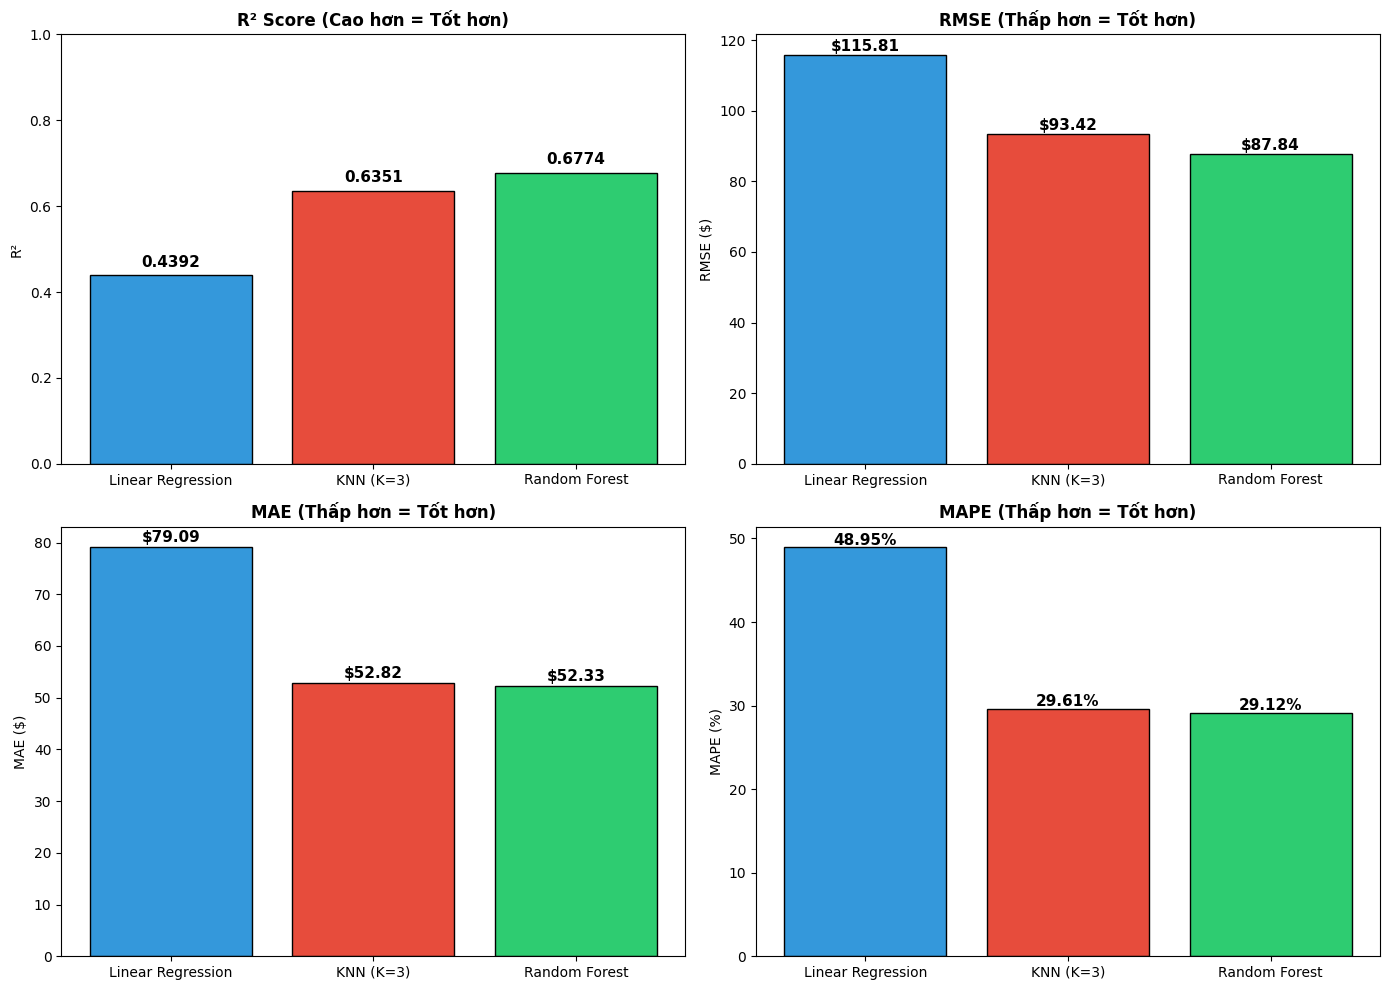

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['Linear Regression', f'KNN (K={optimal_k})', 'Random Forest']
colors = ['#3498db', '#e74c3c', '#2ecc71'] 

# 1. R² Score
axes[0, 0].bar(models, [r2_lr, r2_knn, r2_rf], color=colors, edgecolor='black')
axes[0, 0].set_title('R² Score (Cao hơn = Tốt hơn)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('R²')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate([r2_lr, r2_knn, r2_rf]):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# 2. RMSE
axes[0, 1].bar(models, [rmse_lr, rmse_knn, rmse_rf], color=colors, edgecolor='black')
axes[0, 1].set_title('RMSE (Thấp hơn = Tốt hơn)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('RMSE ($)')
for i, v in enumerate([rmse_lr, rmse_knn, rmse_rf]):
    axes[0, 1].text(i, v + 1, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')

# 3. MAE
axes[1, 0].bar(models, [mae_lr, mae_knn, mae_rf], color=colors, edgecolor='black')
axes[1, 0].set_title('MAE (Thấp hơn = Tốt hơn)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('MAE ($)')
for i, v in enumerate([mae_lr, mae_knn, mae_rf]):
    axes[1, 0].text(i, v + 1, f'${v:.2f}', ha='center', fontsize=11, fontweight='bold')

# 4. MAPE
axes[1, 1].bar(models, [mape_lr, mape_knn, mape_rf], color=colors, edgecolor='black')
axes[1, 1].set_title('MAPE (Thấp hơn = Tốt hơn)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MAPE (%)')
for i, v in enumerate([mape_lr, mape_knn, mape_rf]):
    axes[1, 1].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/so_sanh_3_model.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
best_r2_model = models[np.argmax([r2_lr, r2_knn, r2_rf])]
best_rmse_model = models[np.argmin([rmse_lr, rmse_knn, rmse_rf])]
best_mae_model = models[np.argmin([mae_lr, mae_knn, mae_rf])]
best_mape_model = models[np.argmin([mape_lr, mape_knn, mape_rf])]

# so sánh và kết luận
comparison_formatted = pd.DataFrame({
    'Metric': ['R²', 'RMSE ($)', 'MAE ($)', 'MAPE (%)'],
    'Linear Regression': [f'{r2_lr:.4f}', f'${rmse_lr:.2f}', f'${mae_lr:.2f}', f'{mape_lr:.2f}%'],
    'KNN': [f'{r2_knn:.4f}', f'${rmse_knn:.2f}', f'${mae_knn:.2f}', f'{mape_knn:.2f}%'],
    'Random Forest': [f'{r2_rf:.4f}', f'${rmse_rf:.2f}', f'${mae_rf:.2f}', f'{mape_rf:.2f}%'],
    'Model tốt nhất': [best_r2_model, best_rmse_model, best_mae_model, best_mape_model]
})

display(comparison_formatted)

win_counts = comparison_formatted['Model tốt nhất'].value_counts()
overall_winner = win_counts.index[0]
winner_score = win_counts.iloc[0]

print(f"Mô hình tốt nhất là {overall_winner}")
if overall_winner == 'Random Forest':
    print("Khuyến nghị: Sử dụng Random Forest cho hệ thống định giá tự động.")

,Metric,Linear Regression,KNN,Random Forest,Model tốt nhất
0,R²,0.4392,0.6351,0.6774,Random Forest
1,RMSE ($),$115.81,$93.42,$87.84,Random Forest
2,MAE ($),$79.09,$52.82,$52.33,Random Forest
3,MAPE (%),48.95%,29.61%,29.12%,Random Forest


Mô hình tốt nhất là Random Forest
Khuyến nghị: Sử dụng Random Forest cho hệ thống định giá tự động.


10 đặc trưng ảnh hưởng nhiều nhất đến giá


,Đặc trưng,Mức độ đóng góp (%)
0,accommodates,39.466833
1,occupancy_rate,10.588724
2,bath_qty,5.165624
3,is_shared_bath,4.814934
4,room_type_Private room,4.620643
5,calculated_host_listings_count,4.529915
6,amenities_count,3.539901
7,bedrooms,2.539733
8,has_hair_dryer,2.536010
9,review_scores_rating,2.357400


C:\Users\CMS\AppData\Local\Temp\ipykernel_14396\3521344425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mức độ đóng góp (%)', y='Đặc trưng',


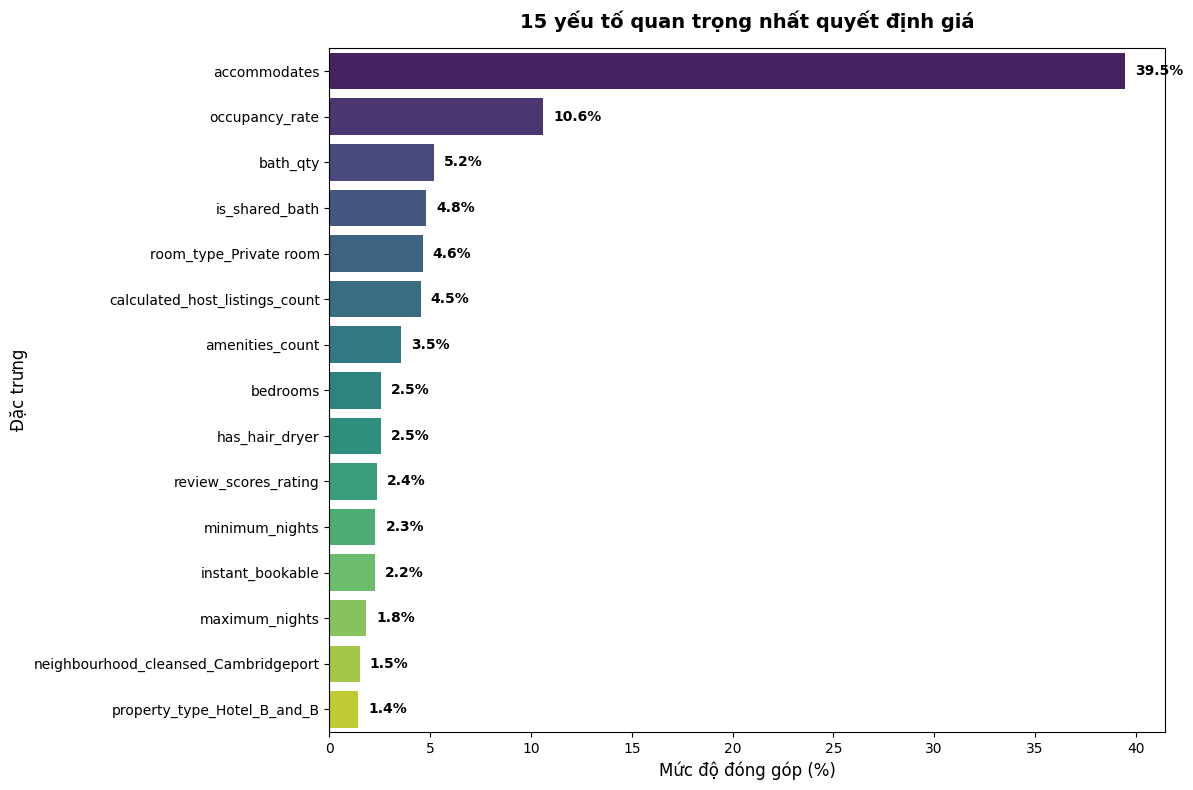

In [42]:
# Trích xuất dữ liệu từ mô hình và ghép với tên cột
# đối thành %
feature_imp = pd.DataFrame({
    'Đặc trưng': X_train_scaled.columns,
    'Mức độ đóng góp (%)': rf_model.feature_importances_ * 100 
}).sort_values(by='Mức độ đóng góp (%)', ascending=False).reset_index(drop=True)

print("10 đặc trưng ảnh hưởng nhiều nhất đến giá")
display(feature_imp.head(10))

# vẽ biểu đồ
plt.figure(figsize=(12, 8))

sns.barplot(x='Mức độ đóng góp (%)', y='Đặc trưng', 
            data=feature_imp.head(15), palette='viridis')

plt.title('15 yếu tố quan trọng nhất quyết định giá', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức độ đóng góp (%)', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)

for index, value in enumerate(feature_imp['Mức độ đóng góp (%)'].head(15)):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', 
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()